In [1]:
#Import libaries
from pathlib import Path
import geopandas
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point
import geodatasets
import seaborn as sns
import numpy as np
import tomllib
import re
from scipy.stats import genextreme


from src.generation.tracks_generation import read_ibtracs, preprocess_ibtracs
from src.data.load_ibtracks import full_processing

#Helper 
def skip_row_func(row_number):
    if (
        row_number == 1
    ):  # skip second row since it contain units, to read the types properly
        return True
    return False

catherina_fit_path = Path(
    "../data/input/fit/Catherina_fit.db"
)

method = "RMSF"
config_path =  "config.toml"

with open(
    config_path,
    "rb",
) as f:  # Open the file in binary mode
    config_files = tomllib.load(f)

In [2]:
#Import data: assets
assets_path = Path("../data/input/assets/ctrace.csv")
assets = pd.read_csv(assets_path)
assets = assets.drop_duplicates(subset="source_id")
assets = assets.loc[lambda row:(row['iso3_country']=='USA'),:]
assets = assets.loc[lambda row:~row['lat'].isna(),:]
sectors = ['fossil-fuel-operations','manufacturing','mineral-extraction','power']
assets_sector = assets.loc[lambda row:row['sector'].isin(sectors),:]
#Compute standard capacity by subsector
assets_agg = assets_sector.groupby(['subsector'])['capacity'].sum().reset_index()

In [4]:
assets_sector.columns

Index(['source_id', 'iso3_country', 'sector', 'subsector', 'start_time',
       'end_time', 'lat', 'lon', 'temporal_granularity', 'activity',
       'activity_units', 'capacity', 'capacity_units'],
      dtype='object')

In [5]:
SAFFIR_SIM_CAT_MS = [32.92, 42.7, 49.3, 58.13, 70.47, 999]
CATEGORY_LABELS = ["Category 1", "Category 2", "Category 3", "Category 4", "Category 5"]

def get_category(wind_speed):
    if wind_speed >= 70:
        return '5'
    elif wind_speed >= 58:
        return '4'
    elif wind_speed >= 50:
        return '3'
    elif wind_speed >= 43:
        return '2'
    elif wind_speed >= 33:
        return '1'
    elif wind_speed >= 0:
        return 'TS'  # Tropical Storm
    
#### Catherina proc
def compute_freq_cath(tracks):
    """
    Compute the frequency of storms in different basins based on wind speed.

    Parameters:
    - tracks: DataFrame containing storm data.
              Expected columns include 'ISO_TIME_POSIXct', 'BASIN', 'wind', 'SID', and 'seed'.

    Returns:
    - df_mean: DataFrame with the mean frequency for each basin.
    - df_std: DataFrame with the standard deviation of frequency for each basin.
    """

    # Extract year from 'ISO_TIME_POSIXct' and filter based on wind speed
    tracks["year"] = pd.to_datetime(tracks["ISO_TIME_POSIXct"]).dt.year
    tracks["BASIN"] = tracks["BASIN"].fillna("NA")
    strong_wind_tracks = tracks[tracks["wind"] > 32.92]

    # Group by SID, seed, and BASIN to get max wind for each group
    max_wind_df = (
        strong_wind_tracks.groupby(["SID", "seed", "BASIN"])["wind"].max().reset_index()
    )

    # Initialize stats list to store frequency data
    stats_list = []
    basins = max_wind_df["BASIN"].unique()
    seeds = max_wind_df["seed"].unique()

    # Compute the normalized frequency for each basin and seed combination
    for basin in basins:
        for seed in seeds:
            subset = max_wind_df[
                (max_wind_df["BASIN"] == basin) & (max_wind_df["seed"] == seed)
            ]
            freq, _ = np.histogram(subset["wind"], bins=SAFFIR_SIM_CAT_MS, density=True)
            freq_normed = freq / freq.sum()
            stats_list.append({"BASIN": basin, "seed": seed, "freq": freq_normed})

    # Convert stats list to DataFrame
    df_stats = pd.DataFrame(stats_list)

    # Compute mean and standard deviation for each basin
    df_mean = (
        df_stats.groupby("BASIN")
        .apply(lambda group: group["freq"].apply(pd.Series).mean())
        .reset_index()
    )
    df_std = (
        df_stats.groupby("BASIN")
        .apply(lambda group: group["freq"].apply(pd.Series).std())
        .reset_index()
    )

    return df_mean, df_std

def compute_storm_frequency(final_storms_df):
    """
    Computes the storm frequency for each basin and category.
    """

    # Categorize storms based on wind speed
    final_storms_df["category"] = pd.cut(
        final_storms_df["wind"],
        bins=SAFFIR_SIM_CAT_MS,
        labels=CATEGORY_LABELS,
        right=False,
        include_lowest=True,
    )

    # Calculate frequency for each basin and category
    all_basins, all_categories, all_frequencies = [], [], []
    for basin in final_storms_df["BASIN"].unique():
        basin_subset = final_storms_df[final_storms_df["BASIN"] == basin]
        freq, _ = np.histogram(
            basin_subset["wind"], bins=SAFFIR_SIM_CAT_MS, density=True
        )
        normed_freq = freq / freq.sum()
        all_basins.extend([basin] * len(CATEGORY_LABELS))
        all_categories.extend(CATEGORY_LABELS)
        all_frequencies.extend(normed_freq)

    # Create the output dataframe
    result_df = pd.DataFrame(
        {"BASIN": all_basins, "category": all_categories, "freq": all_frequencies}
    )

    return result_df

In [6]:
#Read and preprocess ibtracks

ibtracksf_folder = Path(config_files['generation']['ibtracs_path'])
ibtracs = read_ibtracs(fpath=ibtracksf_folder, signed_coords=True)
ibtracs = full_processing(ibtracs)
ibtracs['YEAR'] = ibtracs['ISO_TIME_POSIXct'].dt.year

initiating basic input processing...
retrieving the pressure from IBTrACS...


/home/tropical_cyclones/202509002_code/src/data/load_ibtracks.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ibtracs_pres[num_cols] = ibtracs_pres[num_cols].applymap(convert_to_float)


retrieving and convert winds from IBTrACS...


/home/tropical_cyclones/202509002_code/src/data/load_ibtracks.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ibtracs_winds[num_cols] = ibtracs_winds[num_cols].applymap(convert_to_float)


filtering storm with wind above threshold...


In [9]:
# Load tracks data
tracks_ssp585_dir = Path("../data/input/catherina_test4/intensified_tracks/ACCESS-CM2/ssp585/").rglob("*.parquet")
files = [str(p) for p in tracks_ssp585_dir if p.is_file()]
all_dfs_p1 = []
all_dfs_p2 = []
all_dfs_p3 = []

for p in files :
    if int(re.search(r'seed=\d+', p).group(0)[5:])<100:
        df = pd.read_parquet(p).reset_index().loc[:, ['SID', 'step', 'lat_left', 'lon_left', 'datetime', 'wind_speed', 'basin']].rename(
            columns={"lat_left": "LAT", "lon_left": "LON", 'wind_speed': 'wind', 'basin':'BASIN', 'datetime':'ISO_TIME_POSIXct'}
        )

        df['seed'] = int(re.search(r'seed=\d+', p).group(0)[5:])
        df['year'] = df['ISO_TIME_POSIXct'].dt.year
        all_dfs_p1.append(df.loc[lambda row:row['year']<2050,:])
        all_dfs_p2.append(df.loc[lambda row:(row['year']>=2050)&(row['year']<2075),:])
        all_dfs_p3.append(df.loc[lambda row:row['year']>=2075])

tracks_ssp585_2025_2050 = pd.concat(all_dfs_p1, ignore_index=True)
tracks_ssp585_2050_2075 = pd.concat(all_dfs_p2, ignore_index=True)
tracks_ssp585_2075_2100 = pd.concat(all_dfs_p3, ignore_index=True)

del all_dfs_p1, all_dfs_p2, all_dfs_p3

In [6]:
tracks_ssp585_2025_2050 = tracks_ssp585_2025_2050.loc[lambda row:~row['wind'].isna()]
tracks_ssp585_2050_2075 = tracks_ssp585_2050_2075.loc[lambda row:~row['wind'].isna()]
tracks_ssp585_2075_2100 = tracks_ssp585_2075_2100.loc[lambda row:~row['wind'].isna()]

In [29]:
#sns.ecdfplot(df_asset_wind['q_wind_speed'], color='red')
sns.ecdfplot(tracks_ssp585_2025_2050.loc[:,'wind'], color='green')
sns.ecdfplot(tracks_ssp585_2050_2075.loc[:,'wind'], color='yellow')
sns.ecdfplot(data = tracks_ssp585_2075_2100, x='wind',color='blue')
plt.legend('')

: 

In [7]:
#Get all assets that are exposed

assets_gdf = geopandas.GeoDataFrame(
    assets_sector, geometry=geopandas.points_from_xy(assets_sector['lon'], assets_sector['lat']), crs="EPSG:4326"
)
wind_gdf = geopandas.GeoDataFrame(
    ibtracs, geometry=geopandas.points_from_xy(ibtracs['LON'], ibtracs['LAT']), crs="EPSG:4326"
)

# Convert to a projected coordinate system for distance calculations (e.g., UTM)
# You'll need to choose a UTM zone appropriate for your data's location
assets_gdf_proj = assets_gdf.to_crs(assets_gdf.estimate_utm_crs())
wind_gdf_proj = wind_gdf.to_crs(assets_gdf_proj.crs)  # Use the same CRS as assets_gdf_proj


# Buffer the wind locations by 1000 meters (150 km)
wind_gdf_buffered = wind_gdf_proj.buffer(150*1000)

# Convert the buffered GeoSeries back to a GeoDataFrame
wind_buffer_gdf = geopandas.GeoDataFrame(wind_gdf_proj.loc[:,['SID','YEAR','ISO_TIME_POSIXct','wind']], geometry=wind_gdf_buffered, crs=wind_gdf_proj.crs)

# # 4. Perform a spatial join to find assets within the buffers
assets_exposed_ibtracks = geopandas.sjoin(assets_gdf_proj, 
                                 wind_buffer_gdf, 
                                 predicate='intersects',
                                 how='inner')

assets_exposed_ibtracks = assets_exposed_ibtracks.loc[lambda row:row["wind"]>25.7,:]
list_assets_exposed_ibtracks = assets_exposed_ibtracks['source_id'].unique()
assets_exposed = assets.loc[lambda row:row['source_id'].isin(list_assets_exposed_ibtracks),:]


In [10]:
# Convert asset and wind DataFrames to GeoDataFrames
assets_gdf = geopandas.GeoDataFrame(
    assets_exposed, geometry=geopandas.points_from_xy(assets_exposed['lon'], assets_exposed['lat']), crs="EPSG:4326"
)
wind_gdf = geopandas.GeoDataFrame(
    ibtracs, geometry=geopandas.points_from_xy(ibtracs['LON'], ibtracs['LAT']), crs="EPSG:4326"
)
# Project to a coordinate system with units in meters for buffering
asset_gdf_proj = assets_gdf.to_crs(assets_gdf.estimate_utm_crs())
wind_gdf_proj = wind_gdf.to_crs(asset_gdf_proj.crs)

# Create buffers around assets
asset_gdf_proj['buffer'] = asset_gdf_proj.geometry.buffer(150 * 1000)

# Perform a spatial join to find wind tracks within the asset buffers
wind_in_buffer = geopandas.sjoin(wind_gdf_proj, 
                                 asset_gdf_proj.loc[:,['source_id', 'buffer']].rename(columns={'buffer':'geometry'}), 
                                 predicate='within')


# Group by asset and find the maximum wind speed per SID
def get_max_wind(group):
    idx = group.groupby('SID')['wind'].idxmax()
    return group.loc[idx][['SID', 'ISO_TIME_POSIXct','BASIN', 'wind']].rename(columns={'wind': 'max_wind_speed'})

def get_quantile_wind(group):
    # Calculate the 95th percentile of 'wind' for each group
    q_wind = group.groupby('SID')['wind'].quantile(0.50)

    # Create a DataFrame from the calculated quantiles
    result = pd.DataFrame({'q_wind_speed': q_wind}).reset_index()

    # Merge 'BASIN' assuming it is constant per 'SID'.
    # If 'BASIN' varies within an 'SID', you might need to decide how to aggregate it (e.g., take the first, most frequent).
    #first_basin = group.groupby('SID')['BASIN'].first().reset_index()
    #result = pd.merge(result, first_basin, on='SID', how='left')

    # 'ISO_TIME_POSIXct' is a timestamp for individual wind readings,
    # and doesn't directly apply to a percentile calculated across a group.
    # Therefore, it is excluded from the output.

    return result[['SID', 'q_wind_speed']]


df_asset_wind = wind_in_buffer.groupby('source_id').apply(get_quantile_wind,include_groups=False).reset_index()

In [15]:
# Convert asset and wind DataFrames to GeoDataFrames
assets_gdf = geopandas.GeoDataFrame(
    assets_exposed, geometry=geopandas.points_from_xy(assets_exposed['lon'], assets_exposed['lat']), crs="EPSG:4326"
)

# Project to a coordinate system with units in meters for buffering
asset_gdf_proj = assets_gdf.to_crs(assets_gdf.estimate_utm_crs())

# Create buffers around assets
asset_gdf_proj['buffer'] = asset_gdf_proj.geometry.buffer(150 * 1000)

def get_quantile_wind_seed(group):
    # Calculate the 95th percentile of 'wind' for each group
    q_wind = group.groupby(['SID','seed'])['wind'].quantile(0.50).reset_index()
    q_wind = q_wind.groupby(['SID'])['wind'].mean()

    # Create a DataFrame from the calculated quantiles
    result = pd.DataFrame({'q_wind_speed': q_wind}).reset_index()

    # Merge 'BASIN' assuming it is constant per 'SID'.
    # If 'BASIN' varies within an 'SID', you might need to decide how to aggregate it (e.g., take the first, most frequent).
    #first_basin = group.groupby('SID')['BASIN'].first().reset_index()
    #result = pd.merge(result, first_basin, on='SID', how='left')

    # 'ISO_TIME_POSIXct' is a timestamp for individual wind readings,
    # and doesn't directly apply to a percentile calculated across a group.
    # Therefore, it is excluded from the output.

    return result[['SID', 'q_wind_speed']]

list_result = []
for tracks in [tracks_ssp585_2025_2050,tracks_ssp585_2050_2075,tracks_ssp585_2075_2100] :
    wind_gdf = geopandas.GeoDataFrame(
        tracks, geometry=geopandas.points_from_xy(tracks['LON'], tracks['LAT']), crs="EPSG:4326"
    )
    wind_gdf_proj = wind_gdf.to_crs(asset_gdf_proj.crs)
    # Perform a spatial join to find wind tracks within the asset buffers
    wind_in_buffer_temps = geopandas.sjoin(wind_gdf_proj,
                                    asset_gdf_proj.loc[:,['source_id', 'buffer']].rename(columns={'buffer':'geometry'}), 
                                    predicate='within')
    df_asset_wind_temps = wind_in_buffer_temps.groupby('source_id').apply(get_quantile_wind_seed,include_groups=False).reset_index()

    list_result.append(df_asset_wind_temps)

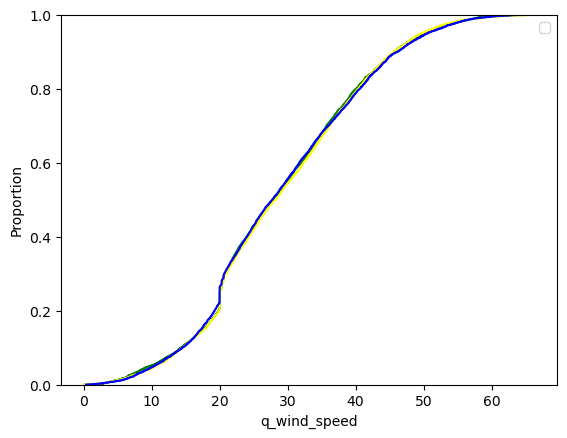

In [17]:
#sns.ecdfplot(df_asset_wind['q_wind_speed'], color='red')
sns.ecdfplot(list_result[0].loc[:,'q_wind_speed'], color='green')
sns.ecdfplot(list_result[1].loc[:,'q_wind_speed'], color='yellow')
sns.ecdfplot(data = list_result[2].loc[:,:], x='q_wind_speed',color='blue')
plt.legend('')

In [25]:
list_result[0]['q_wind_speed'].mean()

np.float64(29.066020635702642)

<Axes: xlabel='q_wind_speed', ylabel='Count'>

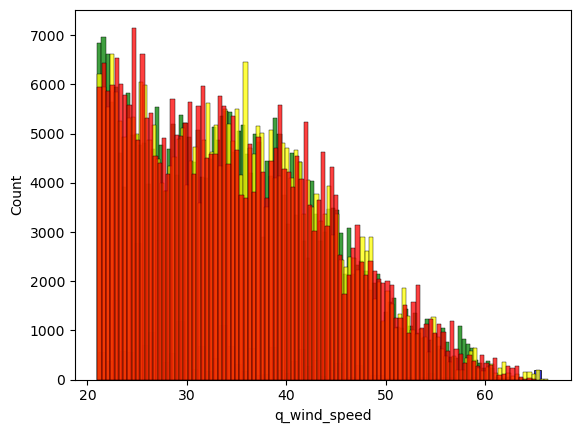

In [27]:
sns.histplot(df_asset_wind.loc[lambda row:row['q_wind_speed']>21,'q_wind_speed'], color='blue')
sns.histplot(list_result[0].loc[lambda row:row['q_wind_speed']>21,'q_wind_speed'], color='green')
sns.histplot(list_result[1].loc[lambda row:row['q_wind_speed']>21,'q_wind_speed'], color='yellow')
sns.histplot(list_result[2].loc[lambda row:row['q_wind_speed']>21,'q_wind_speed'], color='red')

